**Đọc file dataset**  https://www.kaggle.com/datasets/shivamb/go-emotions-google-emotions-dataset/data

In [1]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "go_emotions_dataset.csv"


df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/go-emotions-google-emotions-dataset",
    file_path
)

# Khai báo cấu trúc hệ thống phân loại 28 nhãn chuẩn của Google
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]



/tmp/ipykernel_1335/2057014050.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'go-emotions-google-emotions-dataset' dataset.


**Gom cụm các rater** nếu > 2 người cùng đánh giá 1 câu cùng 1 loại cảm xúc thì giữ, còn lại bỏ

In [2]:
# Gom cụm các rater đánh giá cùng một câu bình luận lại với nhau
grouped = df.groupby(['id', 'text'])[emotion_labels].sum().reset_index()
print(f"Số lượng câu bình luận độc nhất sau khi gom cụm: {len(grouped)} câu.")

# Nhãn cảm xúc nào được ít nhất 2 chuyên gia chọn mới tính là 1, dưới 2 phiếu bầu sẽ bị hủy (= 0)
for col in emotion_labels:
    grouped[col] = (grouped[col] >= 2).astype(int)

# Tính tổng số nhãn được kích hoạt cho mỗi câu
grouped['has_label'] = grouped[emotion_labels].sum(axis=1)
# Chỉ giữ lại các câu có ít nhất 1 nhãn cảm xúc đạt sự đồng thuận từ 2 người trở lên
grouped_clean = grouped[grouped['has_label'] > 0].drop(columns=['has_label'])

print(f"🔹 Số lượng câu bình luận sạch thu được: {len(grouped_clean)} câu.")

# Xem thử 3 dòng đầu tiên sau khi làm sạch
grouped_clean.head(3)

Số lượng câu bình luận độc nhất sau khi gom cụm: 58011 câu.
🔹 Số lượng câu bình luận sạch thu được: 54263 câu.


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,You blew it. They played you like a fiddle.,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Làm sạch dữ liệu**

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
import re
import unicodedata

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):
    # 1. Tránh lỗi crash nếu dữ liệu bị trống (NaN)
    if not isinstance(text, str):
        return ""

    # 2. Đưa về chữ thường
    text = text.lower()

    # Bước A: Đồng bộ hóa mọi loại "dấu nháy"
    text = re.sub(r"[’‘`´]", "'", text)

    # Bước B: Xử lý chữ cái có dấu
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 3. Khai triển từ viết tắt
    text = re.sub(r"i'm", "i am", text)
    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"doesn't", "does not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"isn't", "is not", text)
    text = re.sub(r"aren't", "are not", text)
    text = re.sub(r"haven't", "have not", text)
    text = re.sub(r"hasn't", "has not", text)
    text = re.sub(r"didn't", "did not", text)
    text = re.sub(r"it's", "it is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"you're", "you are", text)
    text = re.sub(r"i've", "i have", text)
    text = re.sub(r"i'll", "i will", text)

    # Vớt những cụm viết tắt đuôi còn sót
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # KỸ THUẬT NỐI TỪ PHỦ ĐỊNH
    text = re.sub(r"\bnot\s+([a-z]+)\b", r"not_\1", text)

    # 4. Lọc ký tự đặc biệt (giữ lại khoảng trắng, a-z, 0-9 và dấu biểu cảm ! ? _)
    text = re.sub(r"[^a-z0-9\s\!\?\_]", " ", text)

    # 5. Ép các ký tự lặp lại vô nghĩa (soooo -> so)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 6. Gom khoảng trắng thừa và cắt tỉa
    text = re.sub(r"\s+", " ", text).strip()

    # ========================================================
    # 7. KỸ THUẬT LEMMATIZATION (Ép gốc từ) - Đã cấy vào cuối hàm
    # ========================================================
    words = text.split()
    # pos='v' giúp ép các động từ (loved, loving, loves) về nguyên thể (love)
    lemmatized_words = [lemmatizer.lemmatize(w, pos='v') for w in words]
    text = " ".join(lemmatized_words)

    return text

# Chạy làm sạch trên tập dữ liệu
grouped_clean = grouped_clean.copy()
grouped_clean = grouped_clean.dropna(subset=['text'])
grouped_clean['text'] = grouped_clean['text'].apply(advanced_clean_text)
grouped_clean = grouped_clean[grouped_clean['text'] != ""]

grouped_clean.head(3)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,fast as name will carry me seriously uptown to...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,you blow it they play you like a fiddle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,tl dr no more superbowls for name get ready fo...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Chia tập train test valid**

In [4]:
from sklearn.model_selection import train_test_split

# 1. Tách ma trận đầu vào X (văn bản sạch) và ma trận đầu ra Y (28 nhãn cảm xúc)
X_text = grouped_clean['text'].astype(str).values
Y_matrix = grouped_clean[emotion_labels].values

# 2. Lần tách thứ nhất: Giữ lại 80% cho tập Train, đẩy 20% còn lại vào tập tạm (Temp)
X_train_text, X_temp_text, Y_train, Y_temp = train_test_split(
    X_text, Y_matrix, test_size=0.20, random_state=42
)

# 3. Lần tách thứ hai: Chia đôi 50/50 tập tạm (Temp) để lấy ra đúng 10% Dev và 10% Test biệt lập
X_val_text, X_test_text, Y_val, Y_test = train_test_split(
    X_temp_text, Y_temp, test_size=0.50, random_state=42
)

print(f"Tập Huấn luyện (Train - 80%): {X_train_text.shape[0]} câu.")
print(f"Tập Phát triển/Kiểm định (Val - 10%): {X_val_text.shape[0]} câu.")
print(f"Tập Kiểm thử (Test - 10%): {X_test_text.shape[0]} câu.")
print(f"Tổng cộng: {X_train_text.shape[0] + X_val_text.shape[0] + X_test_text.shape[0]} câu.")

Tập Huấn luyện (Train - 80%): 43408 câu.
Tập Phát triển/Kiểm định (Val - 10%): 5426 câu.
Tập Kiểm thử (Test - 10%): 5426 câu.
Tổng cộng: 54260 câu.


**TRÍCH XUẤT TF-IDF VECTORIZER**

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

print("SỐ HÓA VĂN BẢN BẰNG BỘ TRÍCH XUẤT TF-IDF VECTORIZER (BẢN NÂNG CẤP MAX/MIN DF)...")

# 1. Lấy danh sách stop_words mặc định và bảo vệ các từ phủ định
custom_stop_words = list(ENGLISH_STOP_WORDS)
words_to_keep = ['not', 'no', 'nor', 'none', 'cannot', 'nothing']

for w in words_to_keep:
    if w in custom_stop_words:
        custom_stop_words.remove(w)

# 2. Khởi tạo TF-IDF với BỘ LỌC ĐÁY và TRẦN
tfidf = TfidfVectorizer(
    max_features= 5000,
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
    min_df=5,       # 🌟 LỌC ĐÁY: Bỏ qua các từ xuất hiện dưới 5 lần
    max_df=0.85     # 🌟 LỌC TRẦN: Bỏ qua các từ xuất hiện ở nhiều hơn 85% số câu
)

# 3. Tiến hành fit và transform trên tập Train
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Chỉ transform (không fit lại) trên tập Val và Test
X_temp_tfidf = tfidf.transform(X_temp_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Kích thước ma trận TF-IDF tập Train: {X_train_tfidf.shape}")

SỐ HÓA VĂN BẢN BẰNG BỘ TRÍCH XUẤT TF-IDF VECTORIZER (BẢN NÂNG CẤP MAX/MIN DF)...
Kích thước ma trận TF-IDF tập Train: (43408, 5000)


In [6]:
from google.colab import files

# 1. Lấy danh sách toàn bộ từ vựng đã học từ TF-IDF
learned_words = tfidf.get_feature_names_out()

# (Tùy chọn) Nếu ông CHỈ MUỐN lấy đúng 500 từ đầu tiên, thì bỏ dấu # ở dòng dưới:
# learned_words = learned_words[:500]

file_name = "Danh_sach_tu_vung_TFIDF.txt"

# 2. Ghi dữ liệu ra file text
with open(file_name, "w", encoding="utf-8") as f:
    for word in learned_words:
        f.write(word + "\n")

print(f"✅ Đã đóng gói thành công {len(learned_words)} từ ra file '{file_name}'!")

# 3. LỆNH THẦN THÁNH: Kích hoạt tải thẳng file xuống máy tính cá nhân
files.download(file_name)

✅ Đã đóng gói thành công 5000 từ ra file 'Danh_sach_tu_vung_TFIDF.txt'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Mô hình Random Forest + TF-IDF**

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import time

# =====================================================================
# BƯỚC 1: ĐỊNH NGHĨA MÔ HÌNH LÕI VỚI CÁC THAM SỐ CHỐNG OVERFITTING
# =====================================================================
base_rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,         # Trồng 100 cây quyết định
    max_depth=50,             # Hạ độ sâu xuống 50 để tránh học vẹt tập Train
    min_samples_split=10,     # Cành chỉ chẻ tiếp nếu có ít nhất 10 câu văn
    min_samples_leaf=2,       # Ngọn lá cuối cùng phải đọng lại ít nhất 2 câu văn
    n_jobs=1,                 # Giữ n_jobs=1 để nhường CPU cho bộ bọc OvR bên ngoài
    random_state=42
)

# =====================================================================
# BƯỚC 2: BỌC MÔ HÌNH BẰNG CHIẾN LƯỢC ONE-VS-REST (OvR)
# =====================================================================
# Kích hoạt n_jobs=-1 ở đây để dùng toàn bộ nhân CPU huấn luyện 28 nhãn cùng lúc
ovr_classifier = OneVsRestClassifier(base_rf_model, n_jobs=-1)

start_time = time.time()

print("Đang tiến hành huấn luyện hệ thống 28 Rừng Ngẫu Nhiên (OvR)... (Vui lòng kiên nhẫn nhé!)")

# BƯỚC 3: TIẾN HÀNH HUẤN LUYỆN
ovr_classifier.fit(X_train_tfidf, Y_train)

end_time = time.time()

print("-" * 70)
print(f"✅ Thời gian mô hình học xong toàn bộ dữ liệu: {end_time - start_time:.2f} giây.")
print("✅ Trạng thái: Hệ thống phân loại 28 nhãn OvR đã sẵn sàng ra quyết định!")

Đang tiến hành huấn luyện hệ thống 28 Rừng Ngẫu Nhiên (OvR)... (Vui lòng kiên nhẫn nhé!)
----------------------------------------------------------------------
✅ Thời gian mô hình học xong toàn bộ dữ liệu: 96.47 giây.
✅ Trạng thái: Hệ thống phân loại 28 nhãn OvR đã sẵn sàng ra quyết định!


**Đánh giá trên tập test**

In [10]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

print("🤖 ĐANG CHẠY THUẬT TOÁN TÌM NGƯỠNG TỐI ƯU TỰ ĐỘNG TRÊN TẬP VAL...")
print("-" * 70)

# =====================================================================
# BƯỚC 1: LẤY XÁC SUẤT THÔ TRÊN TẬP VAL (ĐỂ TÌM NGƯỠNG)
# =====================================================================
# Sử dụng đúng tên biến mô hình từ bước huấn luyện trước
Y_val_proba_list = ovr_classifier.predict_proba(X_val_tfidf)

# Trích xuất cột xác suất của class 1 (Tỉ lệ % thuộc về nhãn đó)
# Y_val_proba_list is already a 2D array where each element (i,j) is P(class 1 | sample i, label j).
# So, we can directly assign it.
Y_val_proba = Y_val_proba_list

# Từ điển lưu ngưỡng tốt nhất của từng nhãn
best_thresholds = {}

# Vòng lặp quét qua từng nhãn trong 28 nhãn
for idx, label in enumerate(emotion_labels):
    best_f1 = 0.0
    best_thresh = 0.5  # Ngưỡng an toàn mặc định

    # Quét thử các ngưỡng từ 0.1 đến 0.95 (mỗi bước nhảy 0.05)
    # Dùng np.round để tránh lỗi trôi dạt số thập phân của float
    for thresh in np.round(np.arange(0.1, 1.0, 0.05), 2):
        # Dự đoán thử với ngưỡng này trên tập Val
        preds = (Y_val_proba[:, idx] >= thresh).astype(int)

        # Tính thử điểm F1-score của riêng nhãn này
        score = f1_score(Y_val[:, idx], preds, zero_division=0)

        # Cập nhật nếu F1 cao hơn
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh

    best_thresholds[label] = best_thresh

print("✅ Đã tìm xong bộ ngưỡng tối ưu cho 28 nhãn dựa trên toán học!")
print("📋 Một số ngưỡng tối ưu tìm được:")
# In gọn 5 nhãn đầu để kiểm tra, tránh làm rối màn hình console
for k in emotion_labels[:5]:
    print(f"   🔹 Sắc thái '{k}': Ngưỡng tối ưu = {best_thresholds[k]:.2f}")
print("   🔹 ... (và 23 nhãn khác)")
print("-" * 70)

# =====================================================================
# BƯỚC 2: ÁP DỤNG BỘ NGƯỠNG HOÀN HẢO NÀY LÊN TẬP TEST MÙ ĐỂ KIỂM THỨ
# =====================================================================
print("📊 TIẾN HÀNH ĐÁNH GIÁ TRÊN TẬP TEST MÙ VỚI BỘ NGƯỠNG MỚI...")

Y_test_proba_list = ovr_classifier.predict_proba(X_test_tfidf)
# Similar to Y_val_proba, Y_test_proba_list is already the desired 2D array.
Y_test_proba = Y_test_proba_list

# Tạo ma trận kết quả trống cho tập Test
Y_pred_opt = np.zeros_like(Y_test)

for idx, label in enumerate(emotion_labels):
    # Lấy ra ngưỡng tối ưu toán học đã tìm được ở Bước 1
    optimal_thresh = best_thresholds[label]
    # Ép sang nhãn 0 hoặc 1 dựa trên ngưỡng chuẩn
    Y_pred_opt[:, idx] = (Y_test_proba[:, idx] >= optimal_thresh).astype(int)

# =====================================================================
# BƯỚC 3: IN BÁO CÁO KẾT QUẢ CUỐI CÙNG
# =====================================================================
print(f"\n📋 BÁO CÁO HIỆU NĂNG RANDOM FOREST (SAU KHI TỐI ƯU NGƯỠNG TỰ ĐỘNG):")
print("=" * 70)
print(classification_report(Y_test, Y_pred_opt, target_names=emotion_labels, zero_division=0))
print("=" * 70)

🤖 ĐANG CHẠY THUẬT TOÁN TÌM NGƯỠNG TỐI ƯU TỰ ĐỘNG TRÊN TẬP VAL...
----------------------------------------------------------------------
✅ Đã tìm xong bộ ngưỡng tối ưu cho 28 nhãn dựa trên toán học!
📋 Một số ngưỡng tối ưu tìm được:
   🔹 Sắc thái 'admiration': Ngưỡng tối ưu = 0.55
   🔹 Sắc thái 'amusement': Ngưỡng tối ưu = 0.55
   🔹 Sắc thái 'anger': Ngưỡng tối ưu = 0.60
   🔹 Sắc thái 'annoyance': Ngưỡng tối ưu = 0.50
   🔹 Sắc thái 'approval': Ngưỡng tối ưu = 0.55
   🔹 ... (và 23 nhãn khác)
----------------------------------------------------------------------
📊 TIẾN HÀNH ĐÁNH GIÁ TRÊN TẬP TEST MÙ VỚI BỘ NGƯỠNG MỚI...

📋 BÁO CÁO HIỆU NĂNG RANDOM FOREST (SAU KHI TỐI ƯU NGƯỠNG TỰ ĐỘNG):
                precision    recall  f1-score   support

    admiration       0.59      0.61      0.60       510
     amusement       0.72      0.86      0.78       316
         anger       0.46      0.39      0.42       184
     annoyance       0.23      0.43      0.30       314
      approval       0.32  

**Confusion matix của 28 mô hình**

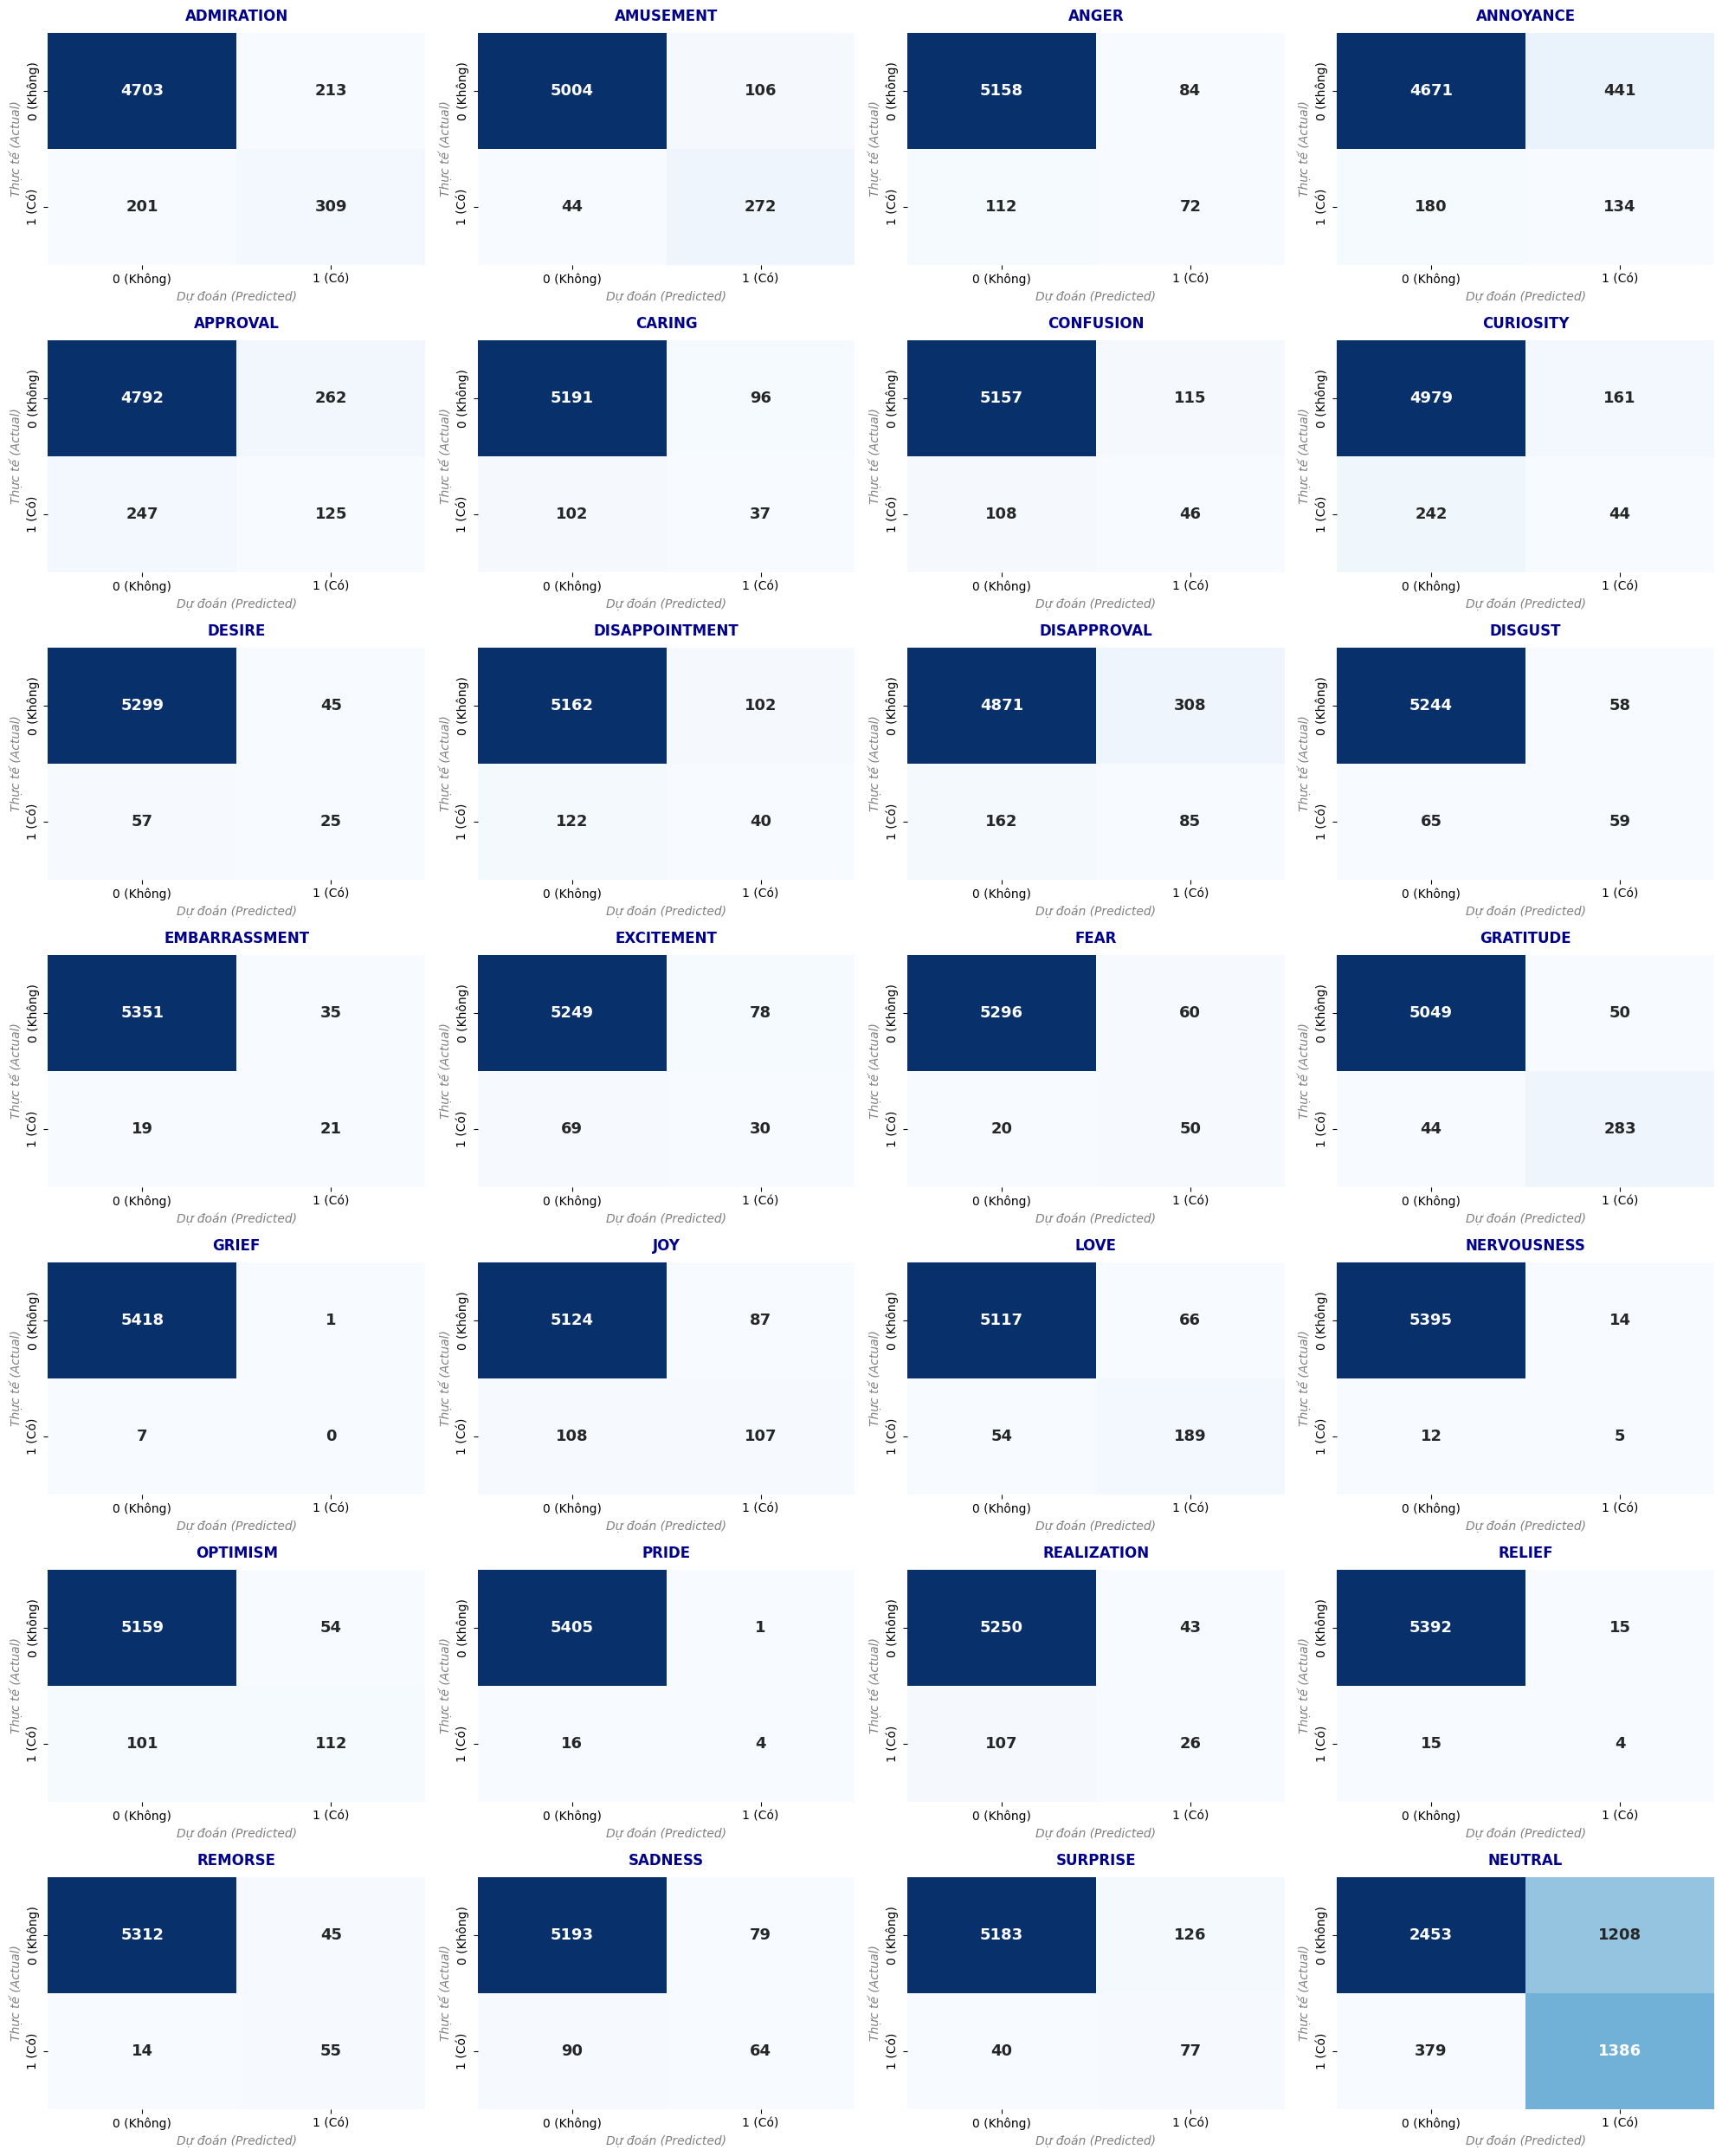

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# Tính toán ma trận nhầm lẫn đa nhãn dựa trên kết quả tối ưu
mcm = multilabel_confusion_matrix(Y_test, Y_pred_opt)

# Khởi tạo khung vẽ: 7 hàng, 4 cột để vừa khít 28 nhãn
fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, label in enumerate(emotion_labels):
    ax = axes[idx]

    # Vẽ Heatmap cho từng nhãn
    sns.heatmap(
        mcm[idx],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['0 (Không)', '1 (Có)'], # Bật lại để biết nhãn dự đoán
        yticklabels=['0 (Không)', '1 (Có)'], # Bật lại để biết nhãn gốc
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"}
    )

    # Trang trí tiêu đề và trục
    ax.set_title(f"{label.upper()}", fontsize=12, fontweight='bold', color='darkblue', pad=10)
    ax.set_xlabel("Dự đoán (Predicted)", fontsize=10, color='gray', style='italic')
    ax.set_ylabel("Thực tế (Actual)", fontsize=10, color='gray', style='italic')

# Căn chỉnh để các biểu đồ không bị đè chữ lên nhau
plt.tight_layout()
plt.show()

**Live test (nhập text và dự đoán)**

In [14]:
import numpy as np

print("Nhập một câu tiếng Anh bất kỳ để xem mô hình tính toán % xác suất độc lập.")
print("Gõ 'exit', 'thoat' để dừng chương trình.\n")

while True:
    user_input = input("✍️ Nhập bình luận tiếng Anh: ")

    if user_input.lower() in ['thoát', 'thoat', 'exit', 'quit']:
        print("👋 Đã đóng cổng thực nghiệm thành công!")
        break

    if user_input.strip() == "":
        continue

    # 1. Ép câu văn đi qua hàm làm sạch văn bản nâng cao
    cleaned_input = advanced_clean_text(user_input)

    # 2. Chuyển đổi văn bản thành vector TF-IDF dựa trên bộ từ vựng đã học
    input_tfidf = tfidf.transform([cleaned_input])

    # 3. Dự đoán xác suất thô từ hệ thống 28 Rừng Ngẫu Nhiên
    raw_probas = ovr_classifier.predict_proba(input_tfidf)

    print(f'\n栏 Câu gốc nhập vào : "{user_input}"')
    print(f'✨ Sau khi làm sạch  : "{cleaned_input}"')
    print("🤖 ĐỘ TỰ TIN XÁC SUẤT VÀ TRẠNG THÁI KÍCH HOẠT:")

    activated_any = False
    all_scores = []

    # 4. Duyệt qua từng bộ phân loại để bóc tách xác suất của lớp 1 (Có cảm xúc)
    # raw_probas is a (1, 28) array, so raw_probas[0] contains the probabilities for the single input.
    for idx, score in enumerate(raw_probas[0]):
        all_scores.append(score)

        label = emotion_labels[idx]
        # ĐÃ NÂNG CẤP: Lấy ngưỡng tối ưu riêng của nhãn này thay vì dùng 0.5 cứng nhắc
        current_thresh = best_thresholds[label]

        # Kiểm tra xem độ tự tin có vượt qua ngưỡng toán học tối ưu không
        if score >= current_thresh:
            print(f"   - [KÍCH HOẠT] {label.upper()}: {score * 100:.2f}% (Ngưỡng chuẩn: {current_thresh:.2f})")
            activated_any = True

    # 5. Cơ chế cứu trợ nếu câu quá ngắn/lạ và không nhãn nào vượt qua được ngưỡng tối ưu
    if not activated_any:
        top_idx = np.argmax(all_scores)
        top_score = all_scores[top_idx]
        top_label = emotion_labels[top_idx]

        if top_score > 0.15:
            print(f"   - {top_label.upper()}: {top_score * 100:.2f}% (Sắc thái tiềm năng nhất - Chưa đạt ngưỡng kích hoạt)")
        else:
            # Lấy chính xác điểm của nhãn 'neutral' từ hệ thống
            neutral_idx = emotion_labels.index('neutral')
            neutral_score = all_scores[neutral_idx]
            print(f"   - NEUTRAL: {neutral_score * 100:.2f}% (Trạng thái trung tính hoàn toàn)")

    print("-" * 70)

Nhập một câu tiếng Anh bất kỳ để xem mô hình tính toán % xác suất độc lập.
Gõ 'exit', 'thoat' để dừng chương trình.

✍️ Nhập bình luận tiếng Anh: "Good luck with your final exam tomorrow, you'll do great!"

栏 Câu gốc nhập vào : ""Good luck with your final exam tomorrow, you'll do great!""
✨ Sau khi làm sạch  : "good luck with your final exam tomorrow you will do great!"
🤖 ĐỘ TỰ TIN XÁC SUẤT VÀ TRẠNG THÁI KÍCH HOẠT:
   - [KÍCH HOẠT] ADMIRATION: 61.54% (Ngưỡng chuẩn: 0.55)
   - [KÍCH HOẠT] CARING: 73.36% (Ngưỡng chuẩn: 0.60)
   - [KÍCH HOẠT] GRATITUDE: 64.98% (Ngưỡng chuẩn: 0.55)
   - [KÍCH HOẠT] OPTIMISM: 85.09% (Ngưỡng chuẩn: 0.60)
----------------------------------------------------------------------
✍️ Nhập bình luận tiếng Anh: I laughed so hard at this that my ribs actually hurt.

栏 Câu gốc nhập vào : "I laughed so hard at this that my ribs actually hurt."
✨ Sau khi làm sạch  : "i laugh so hard at this that my rib actually hurt"
🤖 ĐỘ TỰ TIN XÁC SUẤT VÀ TRẠNG THÁI KÍCH HOẠT:
   - [KÍ

In [22]:
import numpy as np

# =====================================================================
# HÀM MỔ XẺ TRỌNG SỐ (PHIÊN BẢN CHO MULTI-OUTPUT RANDOM FOREST)
# =====================================================================
def mose_random_forest(text, vectorizer, model, class_labels, optimal_thresholds):
    print(f"=== ĐANG MỔ XẺ CÂU: '{text}' ===\n")

    # 1. Chuyển câu thành véc-tơ TF-IDF
    cleaned_text = advanced_clean_text(text)
    vec = vectorizer.transform([cleaned_text])
    feature_names = vectorizer.get_feature_names_out()

    # Lấy vị trí các từ có giá trị > 0 trong ma trận (khác 0)
    nonzero_indices = vec.nonzero()[1]

    if len(nonzero_indices) == 0:
        print("Lỗi: Toàn bộ từ trong câu đều là stop-words hoặc chưa từng xuất hiện trong tập Train.")
        return

    print(f"1. ĐIỂM TF-IDF CỦA TỪNG TỪ SAU KHI LÀM SẠCH ('{cleaned_text}'):")
    for idx in nonzero_indices:
        print(f"   - Từ '{feature_names[idx]}': x = {vec[0, idx]:.4f}")
    print("-" * 70)

    # 2. Lấy danh sách xác suất của cả 28 nhãn
    # predict_proba trả về mảng (1, 28) chứa xác suất của lớp dương cho mỗi nhãn
    probabilities_list = model.predict_proba(vec)
    probs_label_1 = probabilities_list[0]

    print("2. CHI TIẾT ĐÁNH GIÁ CỦA 28 KHU RỪNG NGẪU NHIÊN:\n")
    print("(Lưu ý: Điểm Importance của RF luôn là số dương, biểu thị 'Mức độ đóng góp' vào việc chia nhánh của cây trên toàn cục tập dữ liệu, KHÔNG chỉ ra hướng âm/dương như Logistic)\n")

    activated_labels = []

    for i, label in enumerate(class_labels):
        # Rút 1 khu rừng ngẫu nhiên chuyên xử lý nhãn i
        rf_estimator = model.estimators_[i]
        importances = rf_estimator.feature_importances_
        p = probs_label_1[i]
        thresh = optimal_thresholds[label]

        if p >= thresh:
            activated_labels.append(label.upper())
            print(f"► MÔ HÌNH NHÃN: [{label.upper()}] (Ngưỡng kích hoạt: {thresh:.2f})")
            print("   - Đóng góp cục bộ của các từ trong câu (Gini Importance):")

            for idx in nonzero_indices:
                score = importances[idx]
                print(f"      + Từ '{feature_names[idx]:>15}': Tầm quan trọng = {score:.6f}")

            print(f"   => Xác suất (Tỉ lệ % cây đồng ý): {p:.4f}  --> [ĐÃ KÍCH HOẠT]")
            print("*" * 70)

    print("\n3. TỔNG KẾT:")
    if activated_labels:
        print(f"   => Câu văn kích hoạt các sắc thái: {', '.join(activated_labels)}")
    else:
        print("   => Không kích hoạt sắc thái nào (hoặc trả về NEUTRAL).")

# =====================================================================
# CHẠY THỬ NGHIỆM MỔ XẺ
# =====================================================================
cau_van_test = "I am so excited but also very nervous"

# Sử dụng ovr_classifier thay vì multi_label_classifier
mose_random_forest(cau_van_test, tfidf, ovr_classifier, emotion_labels, best_thresholds)

=== ĐANG MỔ XẺ CÂU: 'I am so excited but also very nervous' ===

1. ĐIỂM TF-IDF CỦA TỪNG TỪ SAU KHI LÀM SẠCH ('i be so excite but also very nervous'):
   - Từ 'excite': x = 0.6391
   - Từ 'nervous': x = 0.7691
----------------------------------------------------------------------
2. CHI TIẾT ĐÁNH GIÁ CỦA 28 KHU RỪNG NGẪU NHIÊN:

(Lưu ý: Điểm Importance của RF luôn là số dương, biểu thị 'Mức độ đóng góp' vào việc chia nhánh của cây trên toàn cục tập dữ liệu, KHÔNG chỉ ra hướng âm/dương như Logistic)

► MÔ HÌNH NHÃN: [EXCITEMENT] (Ngưỡng kích hoạt: 0.60)
   - Đóng góp cục bộ của các từ trong câu (Gini Importance):
      + Từ '         excite': Tầm quan trọng = 0.097951
      + Từ '        nervous': Tầm quan trọng = 0.000000
   => Xác suất (Tỉ lệ % cây đồng ý): 0.7148  --> [ĐÃ KÍCH HOẠT]
**********************************************************************
► MÔ HÌNH NHÃN: [NERVOUSNESS] (Ngưỡng kích hoạt: 0.55)
   - Đóng góp cục bộ của các từ trong câu (Gini Importance):
      + Từ '     

In [19]:
import joblib

# Tạo một dictionary để chứa tất cả các thành phần cần thiết của mô hình
model_package = {
    'ovr_classifier': ovr_classifier,
    'tfidf_vectorizer': tfidf,
    'emotion_labels': emotion_labels,
    'best_thresholds': best_thresholds
}

# Lưu gói mô hình vào một tệp .pkl
joblib.dump(model_package, 'emotion_detection_model.pkl')

print("✅ Đã tạo thành công tệp 'emotion_detection_model.pkl' chứa tất cả các thành phần mô hình!")


✅ Đã tạo thành công tệp 'emotion_detection_model.pkl' chứa tất cả các thành phần mô hình!


In [20]:
from google.colab import files

files.download('emotion_detection_model.pkl')

print("✅ Đã bắt đầu tải xuống tệp 'emotion_detection_model.pkl'...")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đã bắt đầu tải xuống tệp 'emotion_detection_model.pkl'...
